# Daily Sheet Pipeline

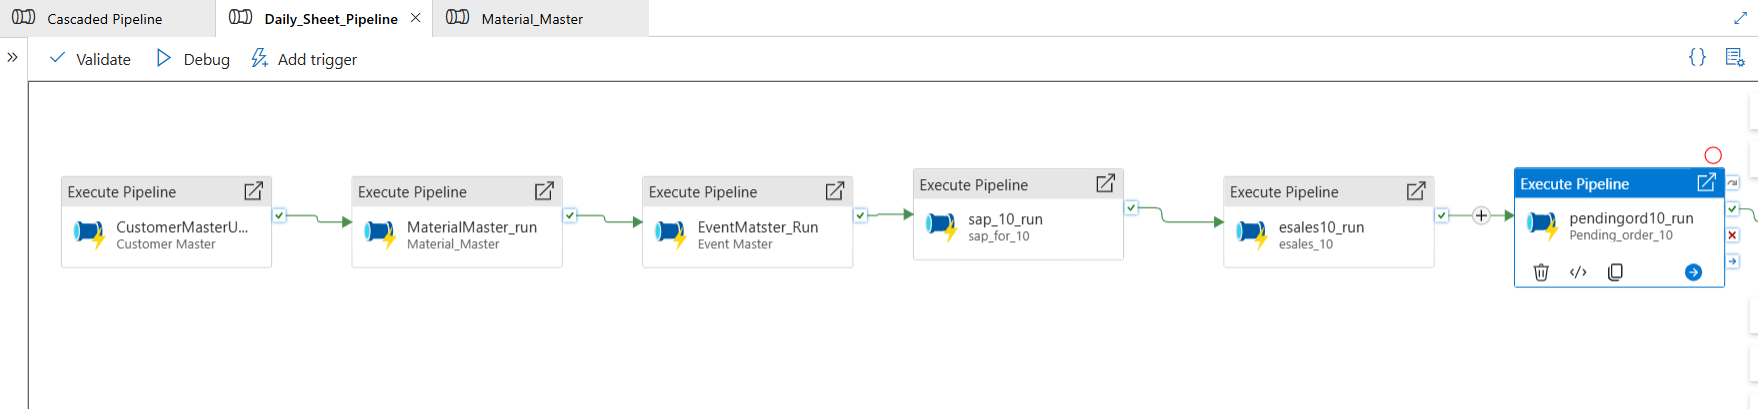

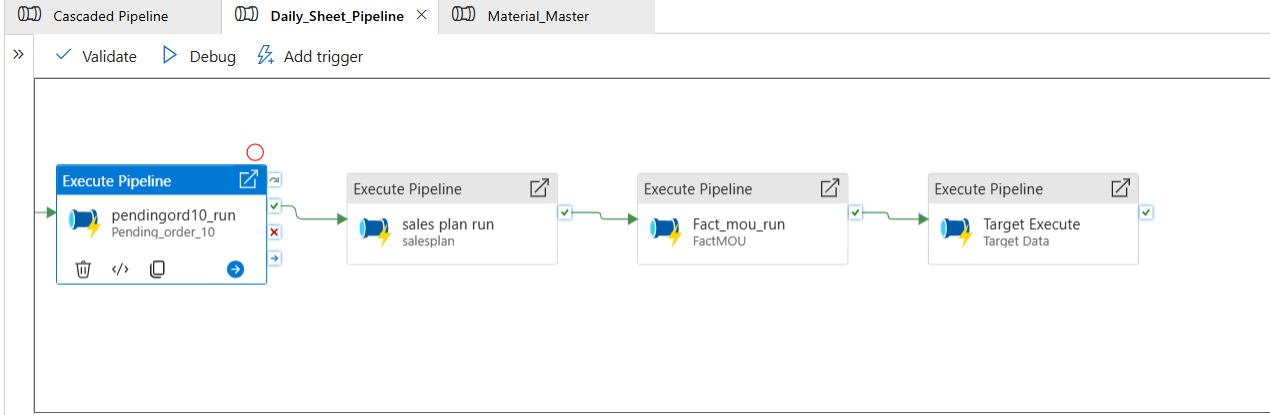

## DBO1 Sheet Pipeline — Customer Master

This pipeline copies customer master data from the FTP source to SQL Server staging and updates the destination table.

## Pipeline Details

- **Data Factory**: `JL-ADF-01`
- **Pipeline Hierarchy**: `Cascaded Pipeline > Sheet Pipeline`
- **Pipeline Name**: `Customer Master`
- **Load Type**: `Full-Load`
- **Lookup Activity Description**: Merges data from `stg.CustomerMaster` into `[dbo1].[DimCustomer_OB]`
- **Log Update**: `NO`

## Source
- **Source Type**: `FTP`
- **Source Linked Service**: `SAP_INPUT_LS`
- **IP**: `11.0.6.219`
- **Source File Folder Path**: `BW_SAP_DATA_DUMP/FEED_FILES`
- **Source File Name / Filter Logic**: `Customer Dump June.xlsx`
- **Source DB Name**: `TestDB`
- **Source Table Name**: `stg.CustomerMaster`
- **Pre Copy Script**: `TRUNCATE TABLE stg.CustomerMaster;`

## Sink

- **Sink Type**: `SQL Server`
- **Sink Linked Service**: `DWH_TestDB`
- **SP Name**: *(None)*
- **dbo Table Name**: `[dbo1].[DimCustomer_OB]`

## Notes

- Copies `Customer Dump June.xlsx` from FTP server (`11.0.6.219`) to staging table `stg.CustomerMaster`.
- Executes `TRUNCATE TABLE stg.CustomerMaster;` before copying new data.
- Merges staging data into `[dbo1].[DimCustomer_OB]` table as a Full-Load process.

## Column Mapping (Source to Destination)

- **Source File Name / Filter Logic**: `Customer Dump June.xlsx`
- **Source DB Name**: `TestDB`
- **Source Table Name**: `stg.CustomerMaster`

| # | Source Column | Source Type | Destination Column | Destination Type |
|---|---|---|---|---|
| 1 | Customer Code | String | Customer Code | nvarchar |
| 2 | Distribution Channel | String | Distribution Channel | nvarchar |
| 3 | Customer Name | String | Customer Name | nvarchar |
| 4 | Region | String | Region | nvarchar |
| 5 | City | String | City | nvarchar |
| 6 | House Number | String | House Number | nvarchar |
| 7 | Postal Code | String | Postal Code | nvarchar |
| 8 | District | String | District | nvarchar |
| 9 | Mail Address | String | Mail Address | nvarchar |
| 10 | Telephone Number | String | Telephone Number | nvarchar |
| 11 | Contact Person | String | Contact Person | nvarchar |
| 12 | Country | String | Country | nvarchar |
| 13 | Street | String | Street | nvarchar |
| 14 | GST | String | GST | nvarchar |
| 15 | Recon. account | String | Recon account | nvarchar |
| 16 | Customer Type | String | Customer Type | nvarchar |
| 17 | PAN | String | PAN | nvarchar |
| 18 | Bank Key | String | Bank Key | nvarchar |
| 19 | Bank Country | String | Bank Country | nvarchar |
| 20 | SWIFT/BIC | String | SWIFT/BIC | nvarchar |
| 21 | Bank Account | String | Bank Account | nvarchar |
| 22 | TAN NO. | String | TAN NO | nvarchar |
| 23 | AAdhaar No. | String | AAdhaar No | nvarchar |
| 24 | Sales Organisation | String | Sales Organization | nvarchar |

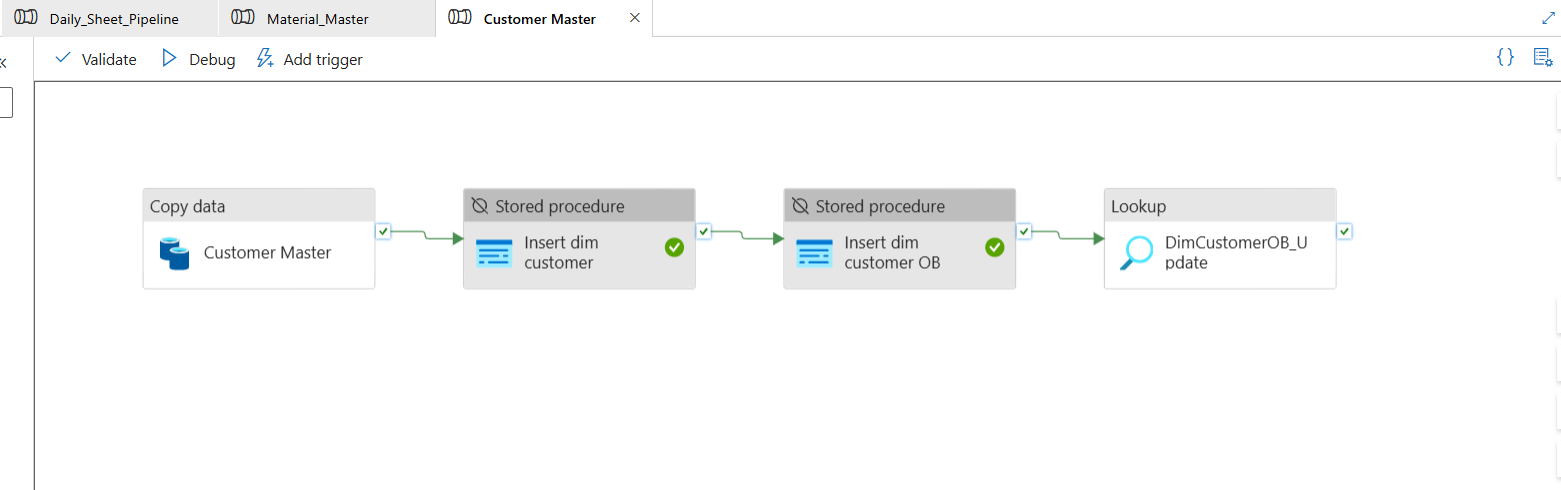

# DBO1 Sheet Pipeline — Material Master

This pipeline ingests material master data from the latest feed file on the FTP server into the SQL Server staging table `[stg].[MaterialMaster]`.

## Pipeline Details

- **Data Factory**: `JL-ADF-01`
- **Pipeline Hierarchy**: `Cascaded Pipeline > Sheet Pipeline`
- **Pipeline Name**: `Material_Master`
- **Load Type**: `Full-Load`
- **Lookup Activity Description**: Ingest data from `BW_SAP_DATA_DUMP` into `stg.MaterialMaster`
- **Log Update**: `NO`

## Source

- **Source Type**: `FTP` (`DelimitedText` / CSV)
- **Source Dataset Name**: `Materialmaster_new_input`
- **Source Linked Service**: `SAP_INPUT_LS`
- **Integration Runtime**: `jl-shir-01`
- **IP**: `11.0.6.219`
- **Source File Folder Path**: `BW_SAP_DATA_DUMP/FEED_FILES`
- **Source File Name / Filter Logic**: Pick latest file from folder (`dataset().filename`)
- **Source DB Name**: `TestDB`
- **Source Table Name**: `[stg].[MaterialMaster]`
- **Pre Copy Script**: `truncate table [stg].[MaterialMaster];`

## Sink

- **Sink Type**: `SQL Server`
- **Sink Linked Service**: `DWH_TestDB`
- **SP Name**: *(None)*
- **dbo Table Name**: *(None)*

## Notes

- Uses dataset `Materialmaster_new_input` (`DelimitedText` CSV format) running on Integration Runtime `jl-shir-01`.
- **File Selection:** Automatically identifies and picks the **latest file** from the `BW_SAP_DATA_DUMP/FEED_FILES` directory via dynamic filename parameterization (`dataset().filename`).
- **Pre-Execution:** Executes `truncate table [stg].[MaterialMaster];` to clear staging before ingestion.
- Direct Full-Load ingestion into `[stg].[MaterialMaster]`.


## Column Mapping (Source to Destination)

- **Source File Name / Filter Logic**: `dataset().filename` *(Picks latest file from folder)*
- **Source DB Name**: `TestDB`
- **Source Table Name**: `[stg].[MaterialMaster]`

| # | Source Column | Source Type | Destination Column | Destination Type |
|---|---|---|---|---|
| 1 | Material Code | String | Material Code | nvarchar |
| 2 | Material Code Description | String | Material Code Description | nvarchar |
| 3 | Batch Class | String | Batch Class | nvarchar |
| 4 | Width | String | Width | nvarchar |
| 5 | Thickness | String | Thickness | nvarchar |
| 6 | External Material Group | String | External Material Group | nvarchar |
| 7 | Material Group | String | MaterialGroup | nvarchar |
| 8 | Material Type | String | Material Type | nvarchar |



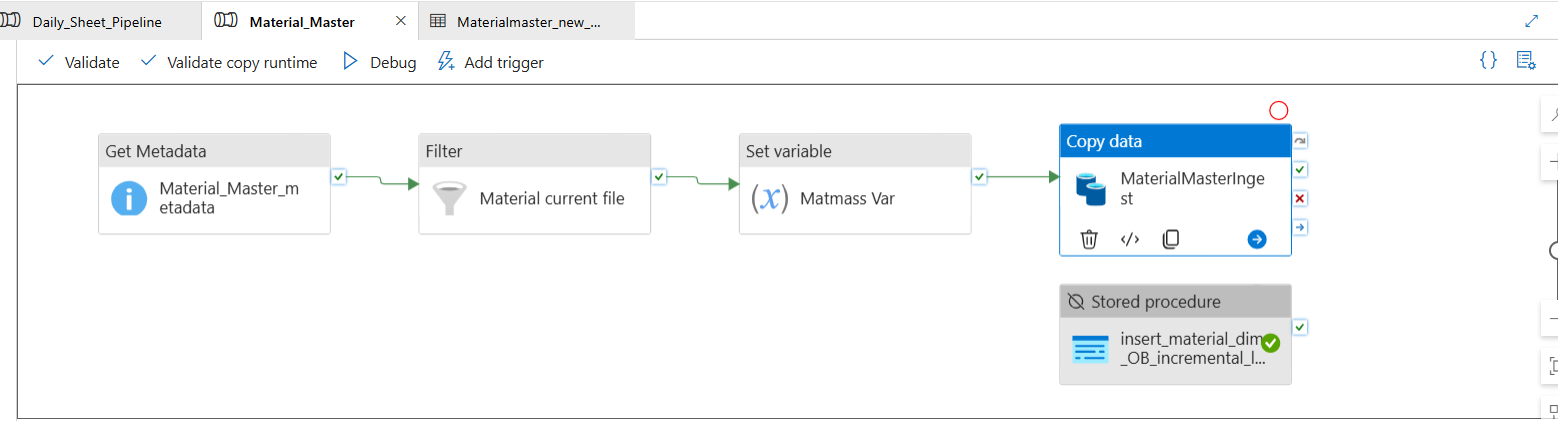

Here is the complete documentation for **Event Master**, formatted according to your exact structure:

---

# DBO1 Sheet Pipeline — Event Master

This pipeline ingests event master data from the FTP source file into the SQL Server staging table `[stg].[EventMaster]`.

## Pipeline Details

- **Data Factory**: `JL-ADF-01`
- **Pipeline Hierarchy**: `Cascaded Pipeline > Sheet Pipeline`
- **Pipeline Name**: `Event Master`
- **Load Type**: `Full-Load`
- **Lookup Activity Description**: Ingest data from `BW_SAP_DATA_DUMP` into `stg.EventMaster`
- **Log Update**: `NO`

## Source

- **Source Type**: `FTP`
- **Source Linked Service**: `SAP_INPUT_LS`
- **IP**: `11.0.6.219`
- **Source File Folder Path**: `BW_SAP_DATA_DUMP/FEED_FILES`
- **Source File Name / Filter Logic**: `Event Master.csv`
- **Source DB Name**: `TestDB`
- **Source Table Name**: `[stg].[EventMaster]`
- **Pre Copy Script**: `Truncate table [stg].[EventMaster];`

## Sink

- **Sink Type**: `SQL Server`
- **Sink Linked Service**: `DWH_TestDB`
- **SP Name**: *(None)*
- **dbo Table Name**: *(None)*

## Column Mapping (Source to Destination)

- **Source File Name / Filter Logic**: `Event Master.csv`
- **Source DB Name**: `TestDB`
- **Source Table Name**: `[stg].[EventMaster]`

| # | Source Column | Source Type | Destination Column | Destination Type |
|---|---|---|---|---|
| 1 | NAME | String | Name | nvarchar |
| 2 | TYPE | String | Type | nvarchar |
| 3 | Frequency | String | Frequency | nvarchar |
| 4 | Main Product | String | Main Product | nvarchar |
| 5 | Product | String | Product | nvarchar |
| 6 | Sub Product | String | Sub Product | nvarchar |
| 7 | Product TYPE | String | Product Type | nvarchar |

## Notes

- Ingests `Event Master.csv` file from FTP directory `BW_SAP_DATA_DUMP/FEED_FILES`.
- Executes `Truncate table [stg].[EventMaster];` prior to loading new records.
- Direct Full-Load ingestion into staging table `[stg].[EventMaster]`.

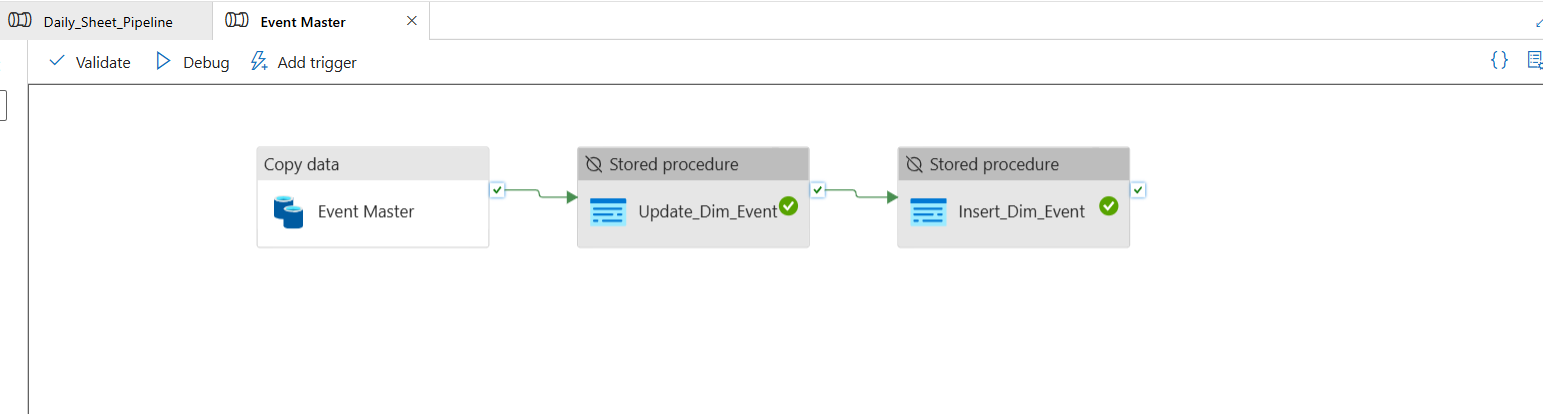

## DBO1 Sheet Pipeline — sap_for_10

This pipeline ingests SAP data from the FTP feed files into the SQL Server staging table `stg.SAPData` and executes a stored procedure to update data formatting.

## Pipeline Details

- **Data Factory**: `JL-ADF-01`
- **Pipeline Hierarchy**: `Cascaded Pipeline > Sheet Pipeline`
- **Pipeline Name**: `sap_for_10`
- **Load Type**: `Full-Load`
- **Lookup Activity Description**: Ingest data from `BW_SAP_DATA_DUMP` into `stg.SAPData`
- **Log Update**: `NO`

## Source

- **Source Type**: `FTP`
- **Source Linked Service**: `SAP_INPUT_LS`
- **IP**: `11.0.6.219`
- **Source File Folder Path**: `BW_SAP_DATA_DUMP/FEED_FILES`
- **Source File Name / Filter Logic**: `dataset().fillenamesap`
- **Source DB Name**: `TestDB`
- **Source Table Name**: `stg.SAPData`
- **Pre Copy Script**: `TRUNCATE TABLE stg.SAPData;`

## Sink

- **Sink Type**: `SQL Server`
- **Sink Linked Service**: `DWH_TestDB`
- **SP Name**: `[dbo1].[sp_update_to_varchar_SAP]`
- **dbo Table Name**: *(None)*

## Column Mapping (Source to Destination)

- **Source File Name / Filter Logic**: `dataset().fillenamesap`
- **Source DB Name**: `TestDB`
- **Source Table Name**: `stg.SAPData`

*(Pending column mapping details — paste the column mapping table when ready)*

## Notes

- Dynamic file name filtering logic using `dataset().fillenamesap`.
- Executes `TRUNCATE TABLE stg.SAPData;` prior to loading new records into staging.
- Executes stored procedure `[dbo1].[sp_update_to_varchar_SAP]` post copy.

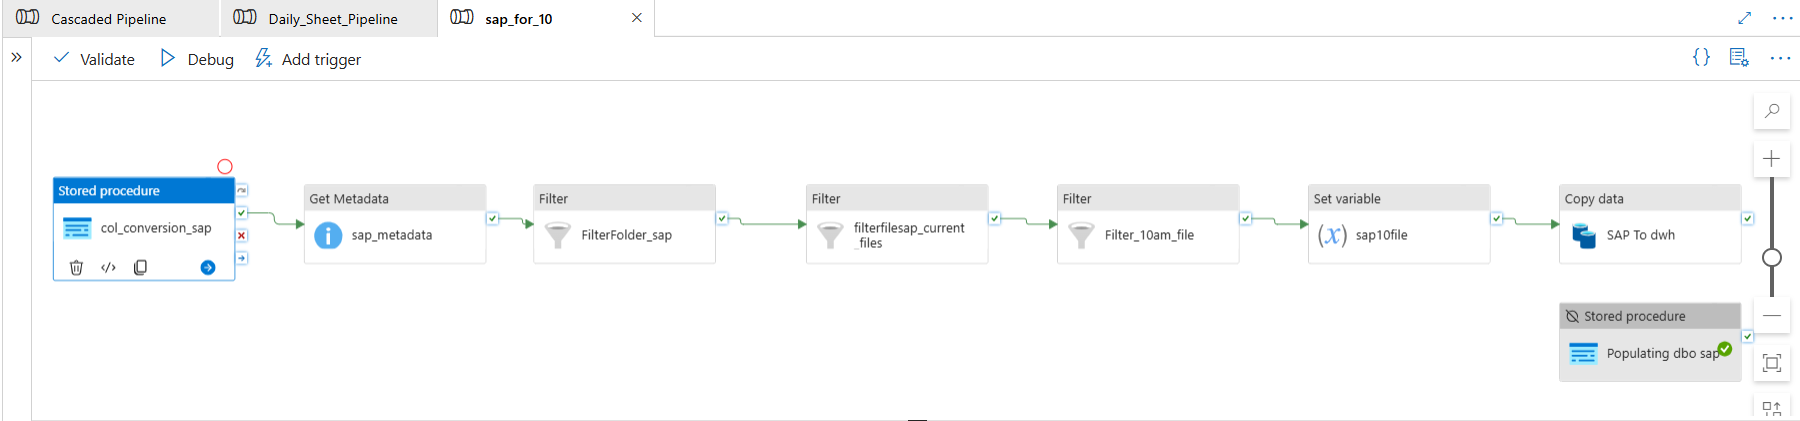

Viewed %5Bdbo1%5D.%5Bupdate_from_stgTodbo_SAP%5D.sql:143-161

Here is the complete documentation for **esales_10**, formatted according to your exact structure:

---

# DBO1 Sheet Pipeline — esales_10

This pipeline ingests events sales data from FTP feed files into the SQL Server staging table `stg.EventsData`.

## Pipeline Details

- **Data Factory**: `JL-ADF-01`
- **Pipeline Hierarchy**: `Cascaded Pipeline > Sheet Pipeline`
- **Pipeline Name**: `esales_10`
- **Load Type**: `Full-Load`
- **Lookup Activity Description**: Ingest data from FTP server into `stg.EventsData`
- **Log Update**: `NO`

## Source

- **Source Type**: `FTP`
- **Source Linked Service**: `SAP_INPUT_LS`
- **IP**: `11.0.6.219`
- **Source File Folder Path**: `BW_SAP_DATA_DUMP/FEED_FILES`
- **Source File Name / Filter Logic**: `SALES_ORDER_FILES_AZURE_DATA`
- **Source DB Name**: `TestDB`
- **Source Table Name**: `stg.EventsData`
- **Pre Copy Script**: `TRUNCATE TABLE stg.EventsData;`

## Sink

- **Sink Type**: `SQL Server`
- **Sink Linked Service**: `DWH_TestDB`
- **SP Name**: *(None)*
- **dbo Table Name**: *(None)*

## Column Mapping (Source to Destination)

- **Source File Name / Filter Logic**: `SALES_ORDER_FILES_AZURE_DATA`
- **Source DB Name**: `TestDB`
- **Source Table Name**: `stg.EventsData`

| # | Source Column | Source Type | Destination Column | Destination Type |
|---|---|---|---|---|
| 1 | Event ID | String | Event ID | varchar |
| 2 | Event Title | String | Event Title | varchar |
| 3 | Event Date | String | Event Date | varchar |
| 4 | Company Name | String | Company Name | varchar |
| 5 | Customer Name | String | Customer Name | varchar |
| 6 | Sold To Party | String | Sold To Party | varchar |
| 7 | Ship To Party | String | Ship To Party | varchar |
| 8 | Item Name | String | Item Name | varchar |
| 9 | MG - 1 | String | MG-1 | varchar |
| 10 | MG - 2 | String | MG-2 | varchar |
| 11 | MG - 3 | String | MG-3 | varchar |
| 12 | MG - 4 | String | MG-4 | varchar |
| 13 | MG - 5 | String | MG-5 | varchar |
| 14 | Item Plant | String | ItemPlant | varchar |
| 15 | Item Shipping Point | String | Item Shipping Point | varchar |
| 16 | Item Rank | String | ItemRank | varchar |
| 17 | Region Name | String | Region Name | varchar |
| 18 | UOM type | String | UOM type | varchar |
| 19 | Item FOB | String | ItemFOB | varchar |
| 20 | Item Region | String | ItemRegion | varchar |
| 21 | Item Width | String | ItemWidth | varchar |
| 22 | TC GF Column Name 1 | String | TC GF Column Name 1 | varchar |
| 23 | TC GF Column Name 2 | String | TC GF Column Name 2 | varchar |
| 24 | Bidder Qty | String | BidderQty | varchar |
| 25 | Bidder Qty_1 | String | BidderQty 1 | varchar |
| 26 | Bidder Qty_2 | String | BidderQty 2 | varchar |
| 27 | Bidder Amt | String | BidderAmt | varchar |
| 28 | Freight Value | String | FreightValue | varchar |
| 29 | Accept Qty | String | AcceptQty | varchar |
| 30 | Ton Value | String | TonValue | varchar |
| 31 | Mtr. Value | String | Mtr Value | varchar |
| 32 | Accept Amt | String | AcceptAmt | varchar |
| 33 | Action | String | Action | varchar |
| 34 | Customer Remarks | String | CustomerRemarks | varchar |
| 35 | Canceled Qty | String | CanceledQty | varchar |
| 36 | Admin Remarks | String | AdminRemarks | varchar |
| 37 | Header Note | String | HeaderNote | varchar |
| 38 | Order Status | String | OrderStatus | varchar |
| 39 | Post Length H-Name | String | Post Length H-Name | varchar |
| 40 | Post Length Value | String | Post Length Value | varchar |
| 41 | Destination Port | String | Destination Port | varchar |
| 42 | Destination Port Freight Value | String | Destination Port Freight Value | varchar |
| 43 | IP Address | String | IP Address | varchar |
| 44 | Sales Person | String | Sales Person | varchar |
| 45 | Extra Discount Price | String | Extra Discount Price | varchar |
| 46 | Item Material ID | String | Item Material ID | varchar |
| 47 | Decision Taken Date | String | Decision_Taken_Date | varchar |

## Notes

- Ingests `SALES_ORDER_FILES_AZURE_DATA` from FTP directory `BW_SAP_DATA_DUMP/FEED_FILES`.
- Runs `TRUNCATE TABLE stg.EventsData;` before copying data into staging.
- Direct Full-Load copy into staging table `stg.EventsData`.

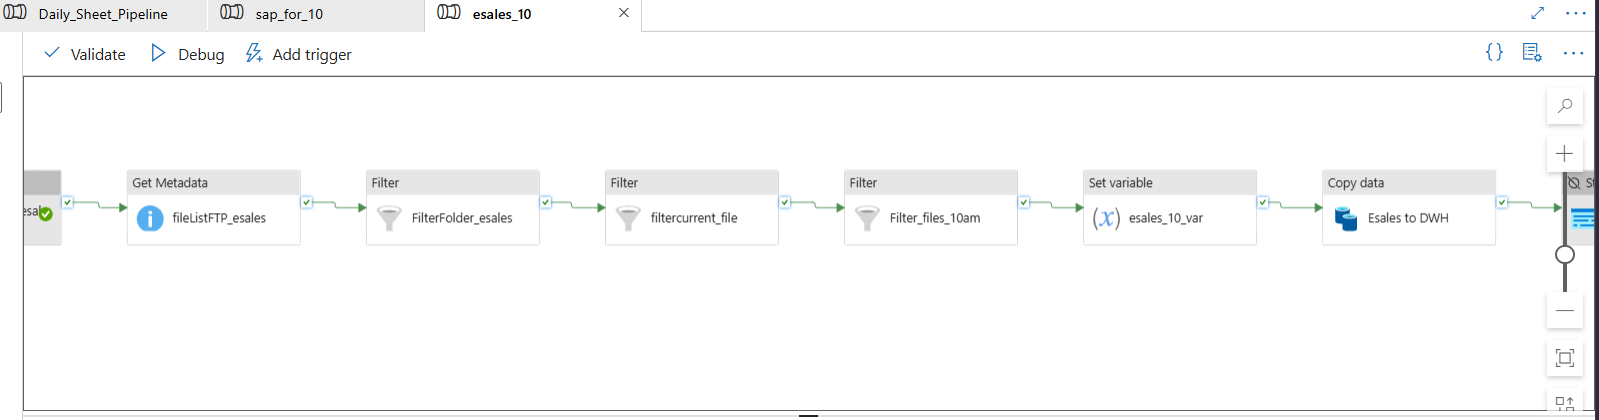